What to Build

Load the CSV from Task 3 and create 3 charts using Matplotlib. Then combine them into a single dashboard figure. Save everything as PNG files.

In [36]:
!pip install matplotlib 


In [37]:
import pandas as pd
import numpy as np
import seaborn as sns  
import matplotlib.pyplot as plt
import os

Task 1

Load DataFrame

In [38]:
# Load data/trends_analysed.csv into a DataFrame
df = pd.read_csv("data/trends_analyzed.csv")

# Create a folder called outputs/ if it doesn't exist
if not os.path.exists("outputs"):
    os.makedirs("outputs")
    print("The outputs/ folder has been created successfully.")
    
# Use plt.savefig() before any plt.show() on all charts
def savefig(name):
    plt.tight_layout()
    plt.savefig(f"plots/{name}.png", dpi=150, bbox_inches='tight')
    print(f"Saved plots/{name}.png successfully")
    plt.close()

Chart 1: Top 10 Stories by Score

In [39]:
# Change the label of the "subreddit" column to "Category"
df = df.rename(columns={"subreddit": "category"}, inplace=False)


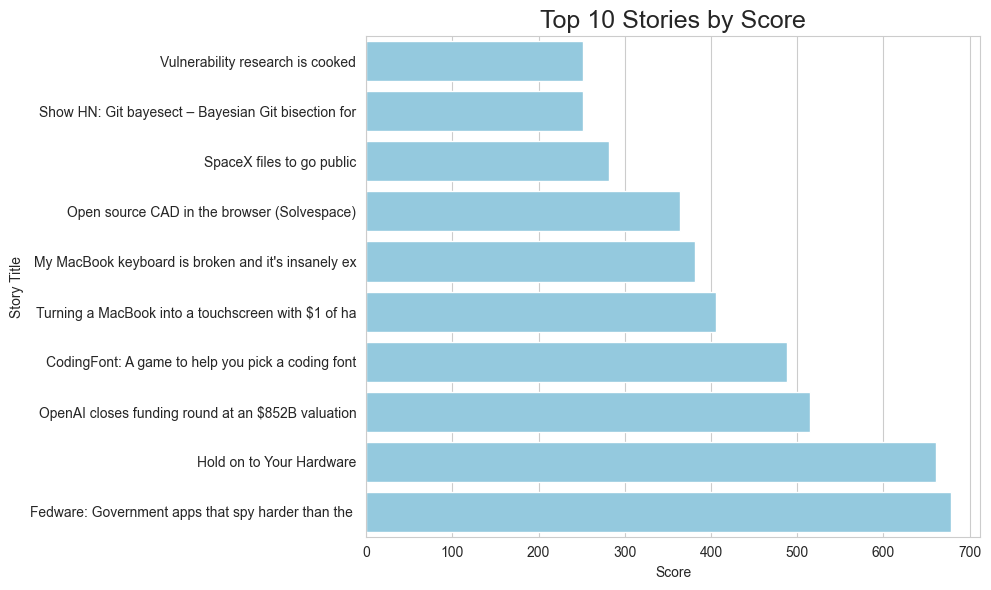

In [50]:
#Create a horizontal bar chart showing the top 10 stories by score
# Use the story title on the y-axis (shorten titles longer than 50 characters)
# Add a title and axis labels
# Save as outputs/chart1_top_stories.png
Top_10_Stories = df.nlargest(10, 'score')[['title', 'score']].copy()
Top_10_Stories['title'] = Top_10_Stories['title'].str.slice(0, 50)
plt.figure(figsize=(10,6))
sns.barplot(x=Top_10_Stories['score'], y=Top_10_Stories['title'], color='skyblue')
plt.xlabel('Score')
plt.ylabel("Story Title")
plt.title("Top 10 Stories by Score", fontsize=18)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("outputs/chart1_top_stories.png")
plt.show()
plt.close()

Chart 2: Stories per Category

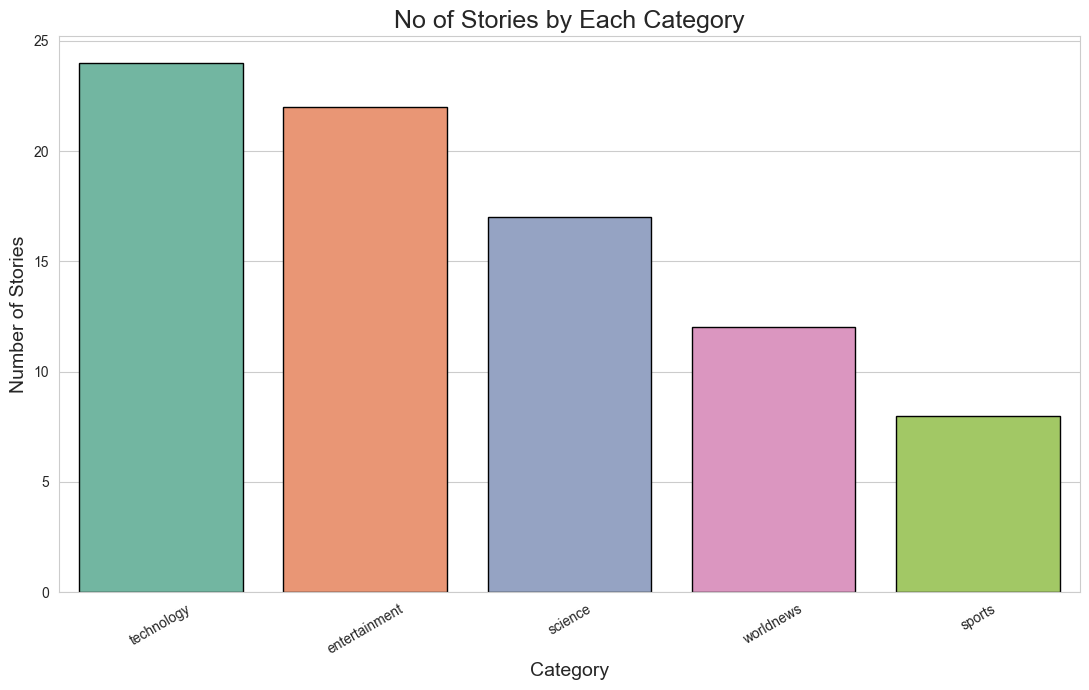

In [46]:
# Create a bar chart showing how many stories came from each category
# Use a different colour for each bar
# Add a title and axis labels
# Save as outputs/chart2_categories.png
category_counts = df["category"].value_counts()
plt.figure(figsize=(11,7))
sns.barplot(x=category_counts.index, y=category_counts.values, palette='Set2', edgecolor='black',hue=category_counts.index)
plt.xlabel("Category", fontsize=14)
plt.ylabel("Number of Stories", fontsize=14)
plt.title("No of Stories by Each Category", fontsize=18)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("outputs/chart2_categories.png")
plt.show()
plt.close()

Chart 3: Score vs Comments

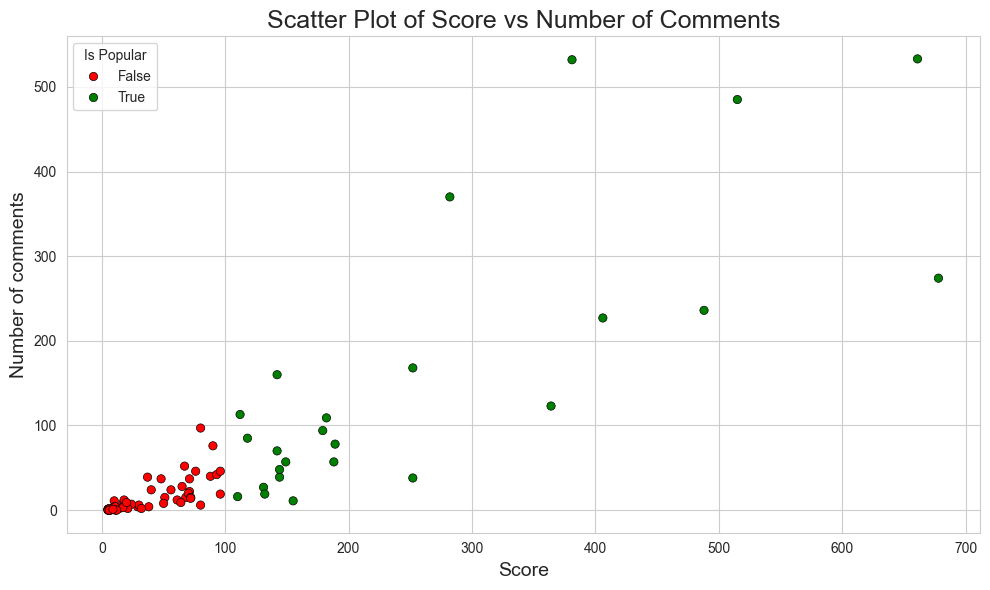

In [48]:
# Create a scatter plot with score on the x-axis and num_comments on the y-axis
# Colour the dots differently for popular vs non-popular stories (use the is_popular column)
# Add a legend, title, and axis labels
# Save as outputs/chart3_scatter.png

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="score", y="num_comments", hue="is_popular", palette={True: 'Green', False: 'Red'}, edgecolor='black')
plt.xlabel("Score", fontsize=14)
plt.ylabel("Number of comments", fontsize=14)
plt.title("Scatter Plot of Score vs Number of Comments", fontsize=18)
plt.legend(title="Is Popular", loc='upper left')
plt.tight_layout()
plt.savefig("outputs/chart3_scatter.png")
plt.show()
plt.close()

Bonus — Dashboard

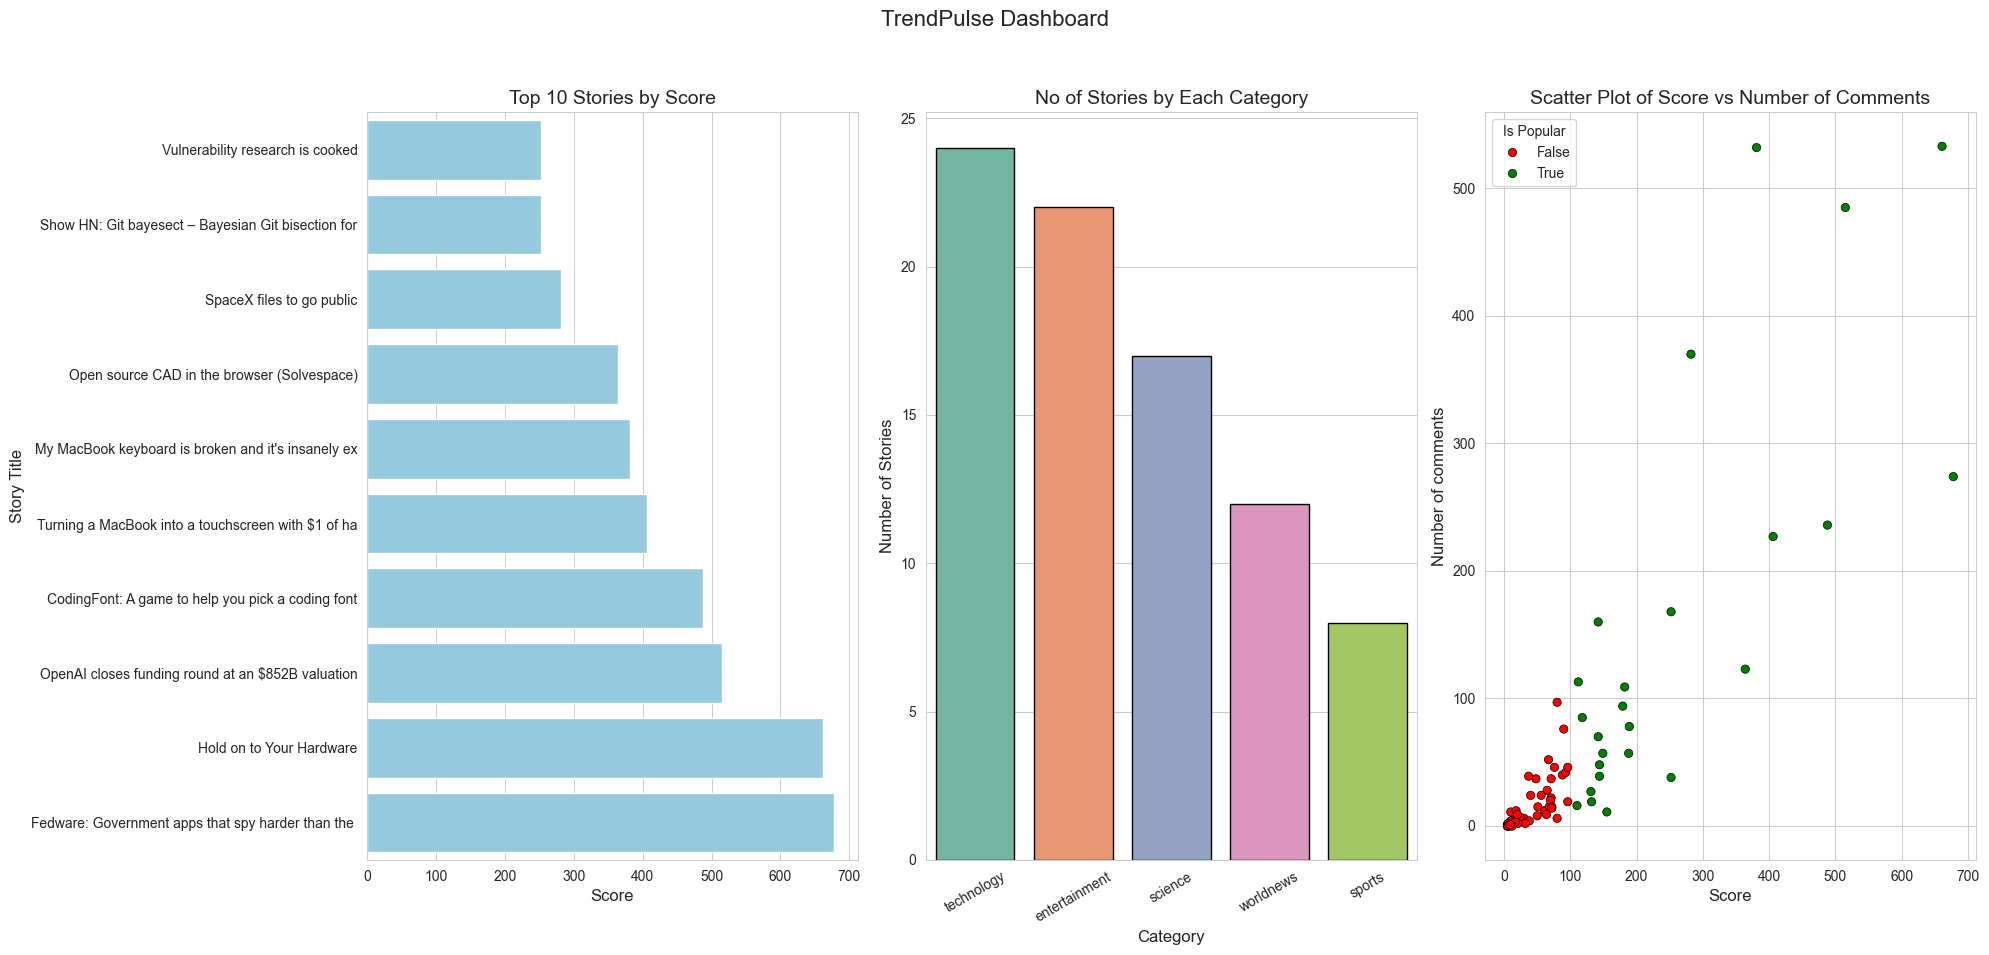

In [51]:
# Combine all 3 charts into one figure:

# Use plt.subplots(1, 3) or plt.subplots(2, 2) to lay them out together
# Add an overall title: "TrendPulse Dashboard"
# Save as outputs/dashboard.png
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
# Chart 1: Top 10 Stories by Score
sns.barplot(x=Top_10_Stories['score'], y=Top_10_Stories['title'], color='skyblue', ax=axes[0])
axes[0].set_xlabel('Score', fontsize=12)
axes[0].set_ylabel("Story Title", fontsize=12)
axes[0].set_title("Top 10 Stories by Score", fontsize=14)
axes[0].invert_yaxis()
# Chart 2: Number of Stories by Each Category
sns.barplot(x=category_counts.index, y=category_counts.values, palette='Set2', edgecolor='black', hue=category_counts.index, ax=axes[1])
axes[1].set_xlabel("Category", fontsize=12)
axes[1].set_ylabel("Number of Stories", fontsize=12)
axes[1].set_title("No of Stories by Each Category", fontsize=14)
axes[1].tick_params(axis='x', rotation=30)
# Chart 3: Scatter Plot of Score vs Number of Comments
sns.scatterplot(data=df, x="score", y="num_comments", hue="is_popular", palette={True: 'Green', False: 'Red'}, edgecolor='black', ax=axes[2])
axes[2].set_xlabel("Score", fontsize=12)
axes[2].set_ylabel("Number of comments", fontsize=12)
axes[2].set_title("Scatter Plot of Score vs Number of Comments", fontsize=14)
axes[2].legend(title="Is Popular", loc='upper left')
fig.suptitle("TrendPulse Dashboard", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("outputs/dashboard.png") 
plt.show()
plt.close() 